# CrossCodeEval — Experiment Result Figures & Tables

This notebook generates all figures and tables for the CrossCodeEval benchmark results.

Data source: `eval/cceval/result/all_results.csv`

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from pathlib import Path

# Paths
RESULT_DIR = Path("../cceval/result")
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load data
df = pd.read_csv(RESULT_DIR / "all_results.csv")

# Separate baseline and RAG configurations
baseline = df[df["method"] == "baseline"].copy()
rag = df[df["method"] != "baseline"].copy()

print(f"Total rows: {len(df)}, RAG rows: {len(rag)}, Baseline rows: {len(baseline)}")
print(f"Methods: {sorted(rag['method'].unique())}")
print(f"Retrievers: {sorted(rag['retriever'].unique())}")
print(f"LLMs: {sorted(rag['llm'].unique())}")
print(f"\nBaseline EM per LLM:")
print(baseline[["llm", "EM"]].to_string(index=False))

Total rows: 725, RAG rows: 720, Baseline rows: 5
Methods: ['cast', 'declaration', 'function', 'sliding']
Retrievers: ['Qwen3-Embedding-0.6B', 'Qwen3-Embedding-4B', 'bm25', 'embeddinggemma-300m']
LLMs: ['Qwen2.5-Coder-7B', 'Qwen3.5-9B-Base', 'Seed-Coder-8B-Base', 'deepseek-coder-6.7b-base', 'starcoder2-7b']

Baseline EM per LLM:
                     llm     EM
deepseek-coder-6.7b-base 0.1043
        Qwen2.5-Coder-7B 0.0305
         Qwen3.5-9B-Base 0.0243
      Seed-Coder-8B-Base 0.0279
           starcoder2-7b 0.0785


## RQ1: Strategy Effect — Table

Same format as RepoEval RQ1 table, single CrossCodeEval column.

In [32]:
# RQ1 — Mean EM per method across all configurations
# Export: output/cceval_rq1_strategy_effect.csv

rq1 = df.groupby("method")["EM"].agg(["mean", "std", "count"]).reset_index()
rq1.columns = ["method", "EM", "std", "n"]
rq1 = rq1.sort_values("method")
rq1.to_csv(OUTPUT_DIR / "cceval_rq1_strategy_effect.csv", index=False)

print("Exported to output/cceval_rq1_strategy_effect.csv")
print(rq1.to_string(index=False))

Exported to output/cceval_rq1_strategy_effect.csv
     method       EM      std   n
   baseline 0.053100 0.036200   5
       cast 0.173473 0.092705 180
declaration 0.164776 0.094172 180
   function 0.136568 0.087364 180
    sliding 0.173770 0.094224 180


## RQ2: Interaction Effect — Tables

In [33]:
# RQ2(a) — Method × Retriever interaction table
# Mean EM across LLM × parameter settings

RETRIEVER_ORDER = ["bm25", "embeddinggemma-300m", "Qwen3-Embedding-0.6B", "Qwen3-Embedding-4B"]

pivot_a = rag.groupby(["method", "retriever"])["EM"].mean().unstack("retriever")
pivot_a.columns.name = None
pivot_a = pivot_a.reindex(index=["function", "declaration", "sliding", "cast"],
                          columns=RETRIEVER_ORDER)
pivot_a.round(4).to_csv(OUTPUT_DIR / "cceval_rq2a_method_retriever.csv")
print("=== RQ2(a) Method × Retriever ===")
print(pivot_a.round(4).to_string())

# RQ2(b) — Method × Generator interaction table
# Mean EM across retriever × parameter settings

LLM_ORDER = ["deepseek-coder-6.7b-base", "starcoder2-7b", "Qwen2.5-Coder-7B", "Qwen3.5-9B-Base", "Seed-Coder-8B-Base"]

pivot_b = rag.groupby(["method", "llm"])["EM"].mean().unstack("llm")
pivot_b.columns.name = None
pivot_b = pivot_b.reindex(index=["function", "declaration", "sliding", "cast"],
                          columns=LLM_ORDER)
pivot_b.round(4).to_csv(OUTPUT_DIR / "cceval_rq2b_method_generator.csv")
print("\n=== RQ2(b) Method × Generator ===")
print(pivot_b.round(4).to_string())

=== RQ2(a) Method × Retriever ===
               bm25  embeddinggemma-300m  Qwen3-Embedding-0.6B  Qwen3-Embedding-4B
method                                                                            
function     0.1309               0.1352                0.1415              0.1387
declaration  0.1570               0.1637                0.1708              0.1676
sliding      0.1674               0.1730                0.1782              0.1765
cast         0.1640               0.1749                0.1766              0.1784

=== RQ2(b) Method × Generator ===
             deepseek-coder-6.7b-base  starcoder2-7b  Qwen2.5-Coder-7B  Qwen3.5-9B-Base  Seed-Coder-8B-Base
method                                                                                                     
function                       0.2563         0.2278            0.0770           0.0618              0.0599
declaration                    0.2901         0.2640            0.1053           0.0891              0.0754
s

## RQ3: Parameter Sensitivity — Line Charts

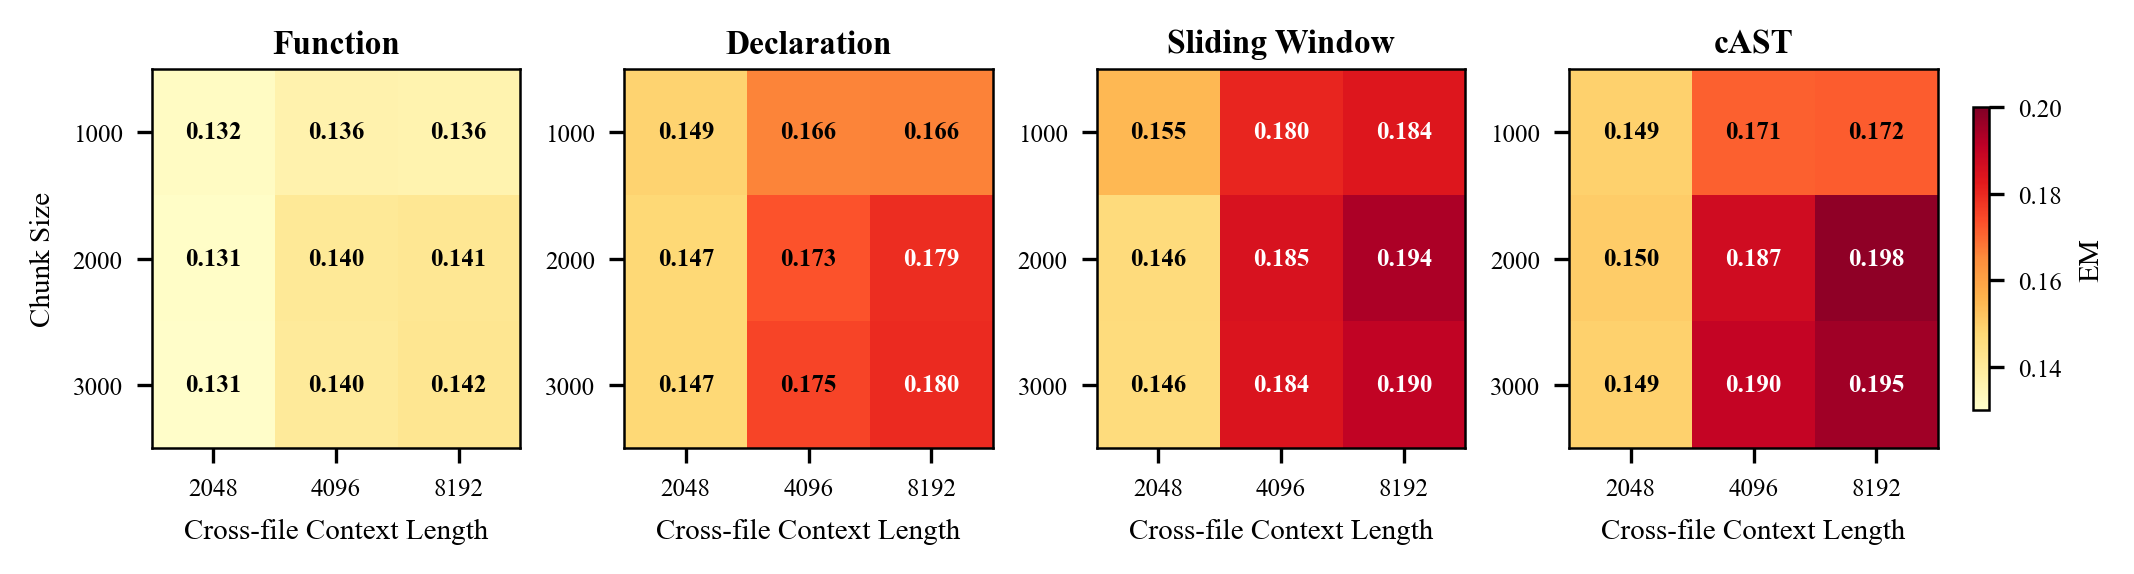

Saved: output/cceval_rq3_heatmap.pdf


In [34]:
# RQ3 — Heatmap: chunk_size × cross-file context length per strategy (1×4 grid)
# Adapted from RepoEval version but without split dimension

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS = ["Function", "Declaration", "Sliding Window", "cAST"]
CHUNK_SIZES = [1000, 2000, 3000]
CONTEXT_LENS = [2048, 4096, 8192]
METRIC = "EM"

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 0.6,
})

# Pre-compute grids
grids = {}
all_vals = []
for method in METHOD_ORDER:
    m = rag[rag["method"] == method]
    grid = np.zeros((len(CHUNK_SIZES), len(CONTEXT_LENS)))
    for r, cs in enumerate(CHUNK_SIZES):
        for c, cl in enumerate(CONTEXT_LENS):
            vals = m[(m["max_chunk_size"] == cs) & (m["max_crossfile_context"] == cl)][METRIC].values
            grid[r, c] = np.mean(vals) if len(vals) > 0 else 0
            all_vals.append(grid[r, c])
    grids[method] = grid

vmin = np.floor(min(all_vals) * 100) / 100
vmax = np.ceil(max(all_vals) * 100) / 100
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd

fig, axes = plt.subplots(1, 4, figsize=(7, 1.8), constrained_layout=True)

for col_idx, (method, mlabel) in enumerate(zip(METHOD_ORDER, METHOD_LABELS)):
    ax = axes[col_idx]
    grid = grids[method]

    im = ax.imshow(grid, cmap=cmap, norm=norm, aspect="auto")

    for r in range(len(CHUNK_SIZES)):
        for c in range(len(CONTEXT_LENS)):
            val = grid[r, c]
            text_color = "white" if norm(val) > 0.65 else "black"
            ax.text(c, r, f"{val:.3f}", ha="center", va="center",
                    fontsize=6, color=text_color, fontweight="bold")

    ax.set_xticks(range(len(CONTEXT_LENS)))
    ax.set_xticklabels([str(c) for c in CONTEXT_LENS], fontsize=6)
    ax.set_yticks(range(len(CHUNK_SIZES)))
    ax.set_yticklabels([str(c) for c in CHUNK_SIZES], fontsize=6)

    ax.set_xlabel("Cross-file Context Length", fontsize=7)
    if col_idx == 0:
        ax.set_ylabel("Chunk Size", fontsize=7)

    ax.set_title(mlabel, fontweight="bold", fontsize=8, pad=4)

# Single colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:], shrink=0.8, pad=0.02, aspect=20)
cbar.ax.tick_params(labelsize=6)
cbar.set_label(METRIC, fontsize=7)

fig.savefig(OUTPUT_DIR / "cceval_rq3_heatmap.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/cceval_rq3_heatmap.pdf")

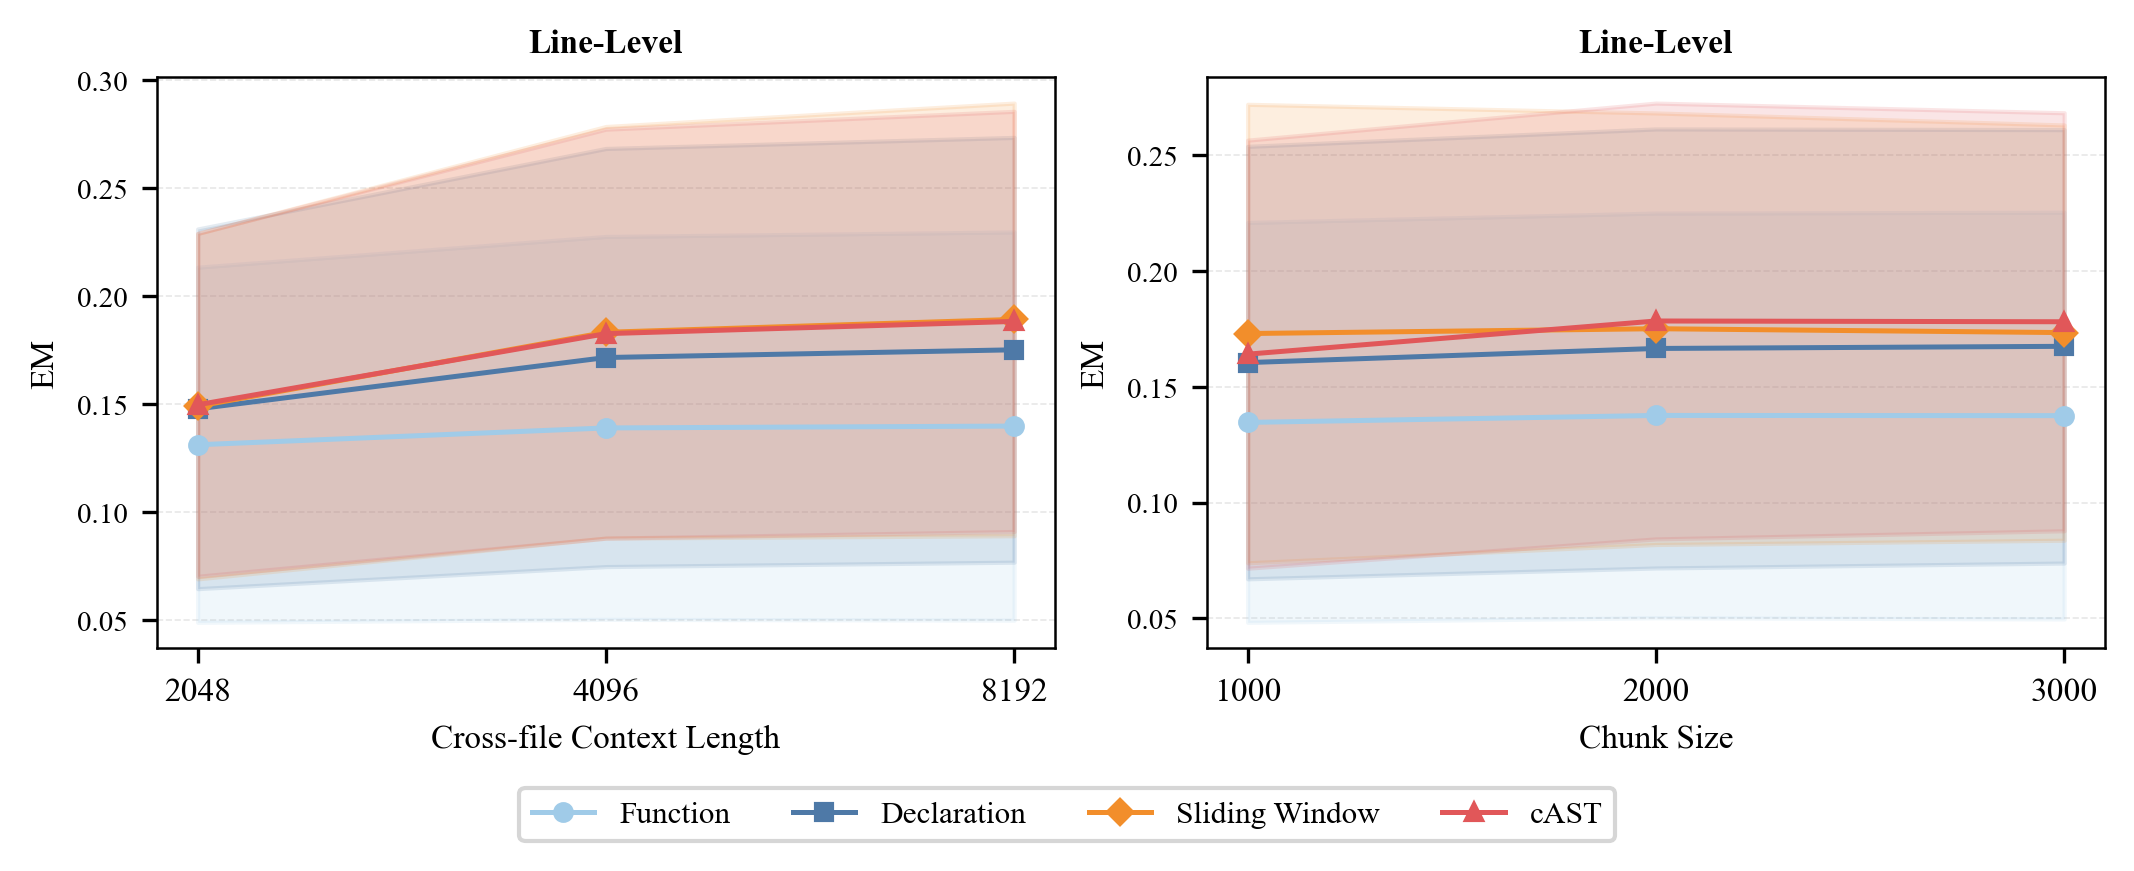

Saved: output/cceval_rq3_line.pdf


In [35]:
# RQ3 — Line chart: parameter sensitivity (1×2 grid)
# Left: EM vs cross-file context length, Right: EM vs chunk size
# 4 method lines with ±1 std shaded bands, aggregated over retriever × LLM.

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS = ["Function", "Declaration", "Sliding Window", "cAST"]
METHOD_COLORS = ['#A0CBE8', '#4E79A7', '#F28E2B', '#E15759']
METHOD_MARKERS = ['o', 's', 'D', '^']
CHUNK_SIZES = [1000, 2000, 3000]
CONTEXT_LENS = [2048, 4096, 8192]
METRIC = "EM"

fig, axes = plt.subplots(1, 2, figsize=(7, 2.5), constrained_layout=True)

# Left: X = cross-file context length
ax = axes[0]
for i, (method, mlabel, color, marker) in enumerate(
    zip(METHOD_ORDER, METHOD_LABELS, METHOD_COLORS, METHOD_MARKERS)
):
    m = rag[rag["method"] == method]
    means, stds = [], []
    for cl in CONTEXT_LENS:
        vals = m[m["max_crossfile_context"] == cl][METRIC].values
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    means, stds = np.array(means), np.array(stds)
    ax.plot(range(len(CONTEXT_LENS)), means, color=color, marker=marker,
            markersize=4, linewidth=1.2, label=mlabel, zorder=3)
    ax.fill_between(range(len(CONTEXT_LENS)), means - stds, means + stds,
                    color=color, alpha=0.15, zorder=1)
ax.set_xticks(range(len(CONTEXT_LENS)))
ax.set_xticklabels([str(c) for c in CONTEXT_LENS])
ax.set_xlabel("Cross-file Context Length", fontsize=8)
ax.set_ylabel(METRIC, fontsize=8)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
ax.set_axisbelow(True)
ax.set_title("Line-Level", fontweight="bold", fontsize=8, pad=6)

# Right: X = chunk size
ax = axes[1]
for i, (method, mlabel, color, marker) in enumerate(
    zip(METHOD_ORDER, METHOD_LABELS, METHOD_COLORS, METHOD_MARKERS)
):
    m = rag[rag["method"] == method]
    means, stds = [], []
    for cs in CHUNK_SIZES:
        vals = m[m["max_chunk_size"] == cs][METRIC].values
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    means, stds = np.array(means), np.array(stds)
    ax.plot(range(len(CHUNK_SIZES)), means, color=color, marker=marker,
            markersize=4, linewidth=1.2, label=mlabel, zorder=3)
    ax.fill_between(range(len(CHUNK_SIZES)), means - stds, means + stds,
                    color=color, alpha=0.15, zorder=1)
ax.set_xticks(range(len(CHUNK_SIZES)))
ax.set_xticklabels([str(c) for c in CHUNK_SIZES])
ax.set_xlabel("Chunk Size", fontsize=8)
ax.set_ylabel(METRIC, fontsize=8)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
ax.set_axisbelow(True)
ax.set_title("Line-Level", fontweight="bold", fontsize=8, pad=6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.12), frameon=True, edgecolor="#cccccc", fontsize=7.5)

fig.savefig(OUTPUT_DIR / "cceval_rq3_line.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/cceval_rq3_line.pdf")

## RQ4: Cost Trade-off — Scatter Plot

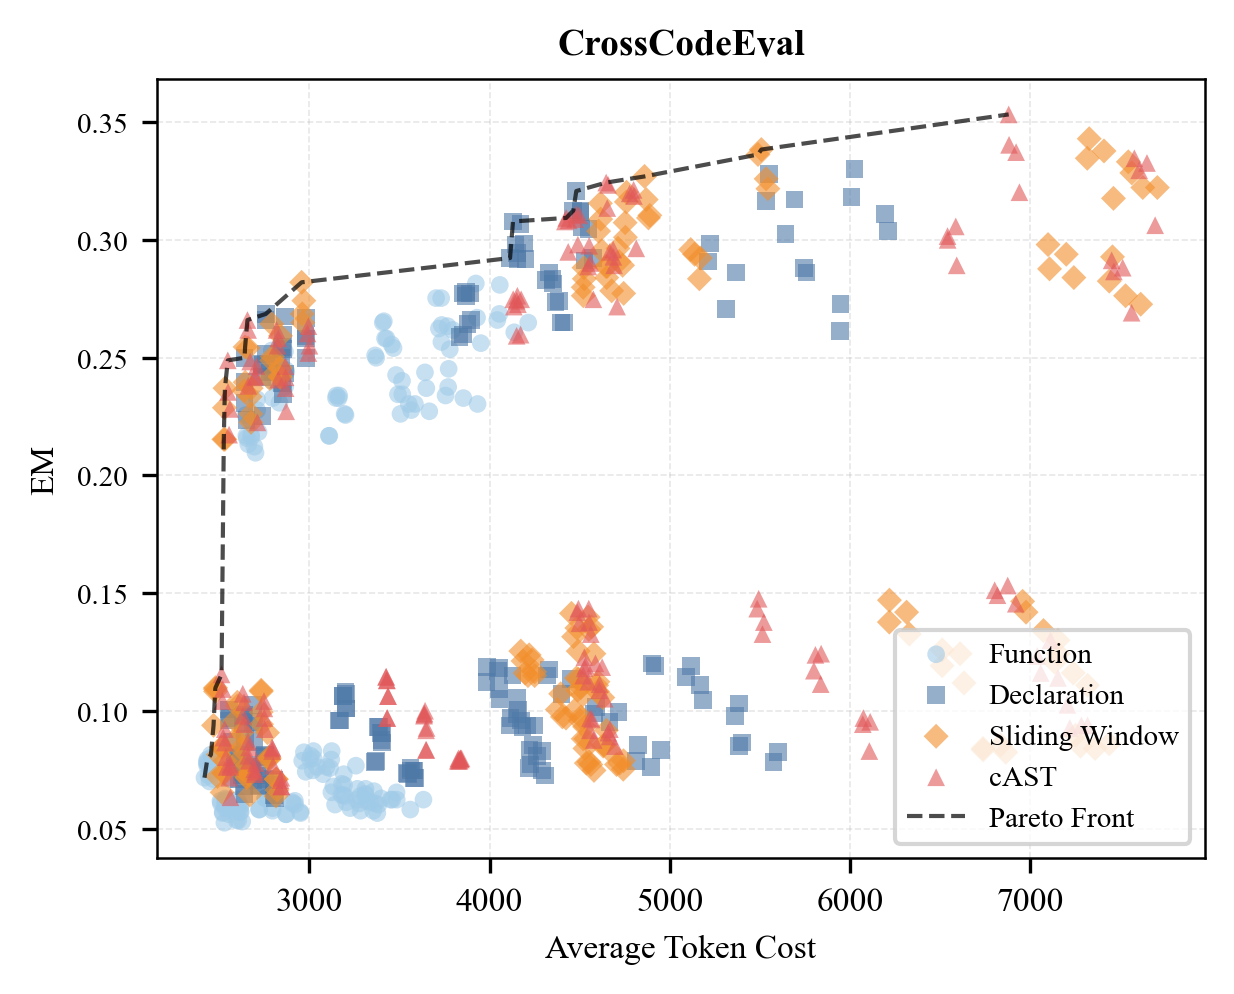

Saved: output/cceval_rq4_pareto.pdf


In [36]:
# RQ4 — Cost-performance scatter plot with Pareto front (single panel)

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS = ["Function", "Declaration", "Sliding Window", "cAST"]
METHOD_COLORS = ['#A0CBE8', '#4E79A7', '#F28E2B', '#E15759']
METHOD_MARKERS = ['o', 's', 'D', '^']
METRIC = "EM"
COST_COL = "avg_token_cost"

def pareto_front(costs, scores):
    """Return indices of Pareto-optimal points (lower cost, higher score)."""
    points = list(zip(costs, scores, range(len(costs))))
    points.sort(key=lambda x: x[0])
    front = []
    best_score = -np.inf
    for cost, score, idx in points:
        if score > best_score:
            front.append(idx)
            best_score = score
    return front

fig, ax = plt.subplots(1, 1, figsize=(4, 3.2), constrained_layout=True)

# Aggregate: each unique config → mean EM, mean cost
agg = rag.groupby(["method", "retriever", "llm", "max_chunk_size", "max_crossfile_context"]).agg(
    em=(METRIC, "mean"),
    cost=(COST_COL, "mean"),
).reset_index()

# Plot each method
for method, mlabel, color, marker in zip(METHOD_ORDER, METHOD_LABELS, METHOD_COLORS, METHOD_MARKERS):
    m = agg[agg["method"] == method]
    ax.scatter(m["cost"], m["em"], c=color, marker=marker,
               s=18, alpha=0.6, label=mlabel, edgecolors="none", zorder=2)

# Compute and plot global Pareto front
all_costs = agg["cost"].values
all_ems = agg["em"].values
front_idx = pareto_front(all_costs, all_ems)
front_costs = all_costs[front_idx]
front_ems = all_ems[front_idx]
sort_order = np.argsort(front_costs)
ax.plot(front_costs[sort_order], front_ems[sort_order],
        color="black", linewidth=1.0, linestyle="--", alpha=0.7, zorder=3, label="Pareto Front")

ax.set_xlabel("Average Token Cost", fontsize=8)
ax.set_ylabel(METRIC, fontsize=8)
ax.set_title("CrossCodeEval", fontweight="bold", fontsize=9, pad=6)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
ax.xaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
ax.set_axisbelow(True)

ax.legend(loc="lower right", fontsize=7, frameon=True, edgecolor="#cccccc")

fig.savefig(OUTPUT_DIR / "cceval_rq4_pareto.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/cceval_rq4_pareto.pdf")